# 05 — Distribution Shift Between Health Systems

## 1. Objective

Locked external validation showed that the frozen System A models lose
transportability when applied to Health System B.

The purpose of this notebook is to characterize potential sources of this
degradation without modifying the frozen models.

The analysis focuses on four forms of cross-system shift:

1. outcome-prevalence shift;
2. predictor distribution shift;
3. feature availability and missingness shift;
4. measurement-intensity shift.

All comparisons use the same frozen landmark at ICU hour 6 and the same
eligible cohorts used for model development and external validation.

This notebook is descriptive and diagnostic. No model is refitted or
recalibrated here.

## 2. Load Frozen System A and System B Feature Matrices

The patient-level matrices created before model evaluation are loaded
directly.

The frozen System A model specification is also loaded so that predictor
roles and ordering remain identical across systems.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd


ROOT = Path.cwd()

if not (ROOT / "data").exists():
    ROOT = ROOT.parent


PROCESSED_DIR = (
    ROOT
    / "data"
    / "processed"
)

FROZEN_DIR = (
    ROOT
    / "results"
    / "frozen"
)

METADATA_DIR = (
    FROZEN_DIR
    / "metadata"
)


SYSTEM_A_FEATURE_PATH = (
    PROCESSED_DIR
    / "system_a_features.csv"
)

SYSTEM_B_FEATURE_PATH = (
    PROCESSED_DIR
    / "system_b_features.csv"
)

MODEL_SPECIFICATION_PATH = (
    METADATA_DIR
    / "system_a_model_specification.json"
)


system_a = pd.read_csv(
    SYSTEM_A_FEATURE_PATH
)

system_b = pd.read_csv(
    SYSTEM_B_FEATURE_PATH
)


with open(
    MODEL_SPECIFICATION_PATH,
    "r",
    encoding="utf-8",
) as file:
    frozen_specification = json.load(file)


feature_columns = (
    frozen_specification[
        "features"
    ][
        "feature_columns"
    ]
)

continuous_feature_columns = (
    frozen_specification[
        "features"
    ][
        "continuous_feature_columns"
    ]
)

binary_feature_columns = (
    frozen_specification[
        "features"
    ][
        "binary_feature_columns"
    ]
)


print(
    f"System A patients: "
    f"{len(system_a):,}"
)

print(
    f"System B patients: "
    f"{len(system_b):,}"
)

print(
    f"Frozen predictors: "
    f"{len(feature_columns)}"
)


assert len(system_a) == 18_699
assert len(system_b) == 17_982
assert len(feature_columns) == 84

assert (
    list(
        system_a[
            feature_columns
        ].columns
    )
    ==
    list(
        system_b[
            feature_columns
        ].columns
    )
)

System A patients: 18,699
System B patients: 17,982
Frozen predictors: 84


## 3. High-Level Cohort Shift

Before examining individual predictors, the two frozen cohorts are
compared on sample size and outcome prevalence.

Because AUPRC, Brier score, and log loss depend partly on outcome
prevalence, this baseline-risk shift is an important context for
interpreting cross-system changes in predictive performance.

In [2]:
high_level_shift_summary = pd.DataFrame(
    [
        {
            "system": "A",
            "patients": len(system_a),
            "events": int(
                system_a[
                    "outcome"
                ].sum()
            ),
            "event_rate": float(
                system_a[
                    "outcome"
                ].mean()
            ),
        },

        {
            "system": "B",
            "patients": len(system_b),
            "events": int(
                system_b[
                    "outcome"
                ].sum()
            ),
            "event_rate": float(
                system_b[
                    "outcome"
                ].mean()
            ),
        },
    ]
)


system_a_event_rate = float(
    system_a["outcome"].mean()
)

system_b_event_rate = float(
    system_b["outcome"].mean()
)


event_rate_ratio_b_to_a = (
    system_b_event_rate
    / system_a_event_rate
)


print(
    f"System B / System A event-rate ratio: "
    f"{event_rate_ratio_b_to_a:.3f}"
)

high_level_shift_summary

System B / System A event-rate ratio: 0.491


,system,patients,events,event_rate
0,A,18699,371,0.019841
1,B,17982,175,0.009732


## 4. Frozen Missingness-Indicator Shift

The primary prediction representation contains explicit availability
indicators for each retained longitudinal variable.

These indicators provide a direct patient-level measure of whether a
clinical variable was observed at least once before or at ICU hour 6.

Differences in availability may reflect both patient characteristics and
health-system-specific measurement practices.

No feature is excluded or redefined based on these comparisons.

In [3]:
availability_columns = [
    col
    for col in feature_columns
    if col.endswith(
        "__available"
    )
]


availability_shift_records = []


for col in availability_columns:
    availability_a = float(
        system_a[col].mean()
    )

    availability_b = float(
        system_b[col].mean()
    )

    availability_shift_records.append(
        {
            "feature":
                col.removesuffix(
                    "__available"
                ),

            "availability_system_a":
                availability_a,

            "availability_system_b":
                availability_b,

            "absolute_difference":
                availability_b
                - availability_a,

            "absolute_percentage_point_difference":
                100
                * (
                    availability_b
                    - availability_a
                ),
        }
    )


availability_shift = pd.DataFrame(
    availability_shift_records
)


availability_shift[
    "absolute_shift_magnitude"
] = (
    availability_shift[
        "absolute_difference"
    ].abs()
)


availability_shift = (
    availability_shift
    .sort_values(
        "absolute_shift_magnitude",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)


print(
    f"Availability indicators compared: "
    f"{len(availability_shift)}"
)

availability_shift.head(15)

Availability indicators compared: 29


,feature,availability_system_a,availability_system_b,absolute_difference,absolute_percentage_point_difference,absolute_shift_magnitude
0,HCO3,0.516070,0.008842,-0.507228,-50.722820,0.507228
1,BaseExcess,0.480988,0.011734,-0.469254,-46.925433,0.469254
2,Chloride,0.516926,0.054833,-0.462093,-46.209343,0.462093
3,DBP,0.562864,0.992214,0.429350,42.935011,0.429350
4,FiO2,0.500508,0.198866,-0.301643,-30.164252,0.301643
5,pH,0.492754,0.203648,-0.289106,-28.910553,0.289106
6,PTT,0.399594,0.132132,-0.267461,-26.746143,0.267461
7,PaCO2,0.466068,0.203815,-0.262253,-26.225278,0.262253
8,Hct,0.617680,0.385219,-0.232462,-23.246154,0.232462
9,Calcium,0.312851,0.472639,0.159788,15.978835,0.159788


### Magnitude of Availability Shift

The magnitude of cross-system availability differences is summarized
before examining clinical-value distributions.

Large differences in availability may indicate changes in measurement
practice, workflow, or documentation behavior across health systems.

These comparisons are descriptive and do not establish the cause of the
observed transportability degradation.

In [4]:
availability_shift_summary = pd.Series(
    {
        "features_compared":
            len(
                availability_shift
            ),

        "features_shift_ge_5pp":
            int(
                (
                    availability_shift[
                        "absolute_shift_magnitude"
                    ] >= 0.05
                ).sum()
            ),

        "features_shift_ge_10pp":
            int(
                (
                    availability_shift[
                        "absolute_shift_magnitude"
                    ] >= 0.10
                ).sum()
            ),

        "features_shift_ge_20pp":
            int(
                (
                    availability_shift[
                        "absolute_shift_magnitude"
                    ] >= 0.20
                ).sum()
            ),

        "features_shift_ge_30pp":
            int(
                (
                    availability_shift[
                        "absolute_shift_magnitude"
                    ] >= 0.30
                ).sum()
            ),

        "maximum_absolute_shift":
            float(
                availability_shift[
                    "absolute_shift_magnitude"
                ].max()
            ),
    },
    name="Availability-shift magnitude",
)

availability_shift_summary.to_frame()

,Availability-shift magnitude
features_compared,29.000000
features_shift_ge_5pp,22.000000
features_shift_ge_10pp,15.000000
features_shift_ge_20pp,9.000000
features_shift_ge_30pp,5.000000
maximum_absolute_shift,0.507228


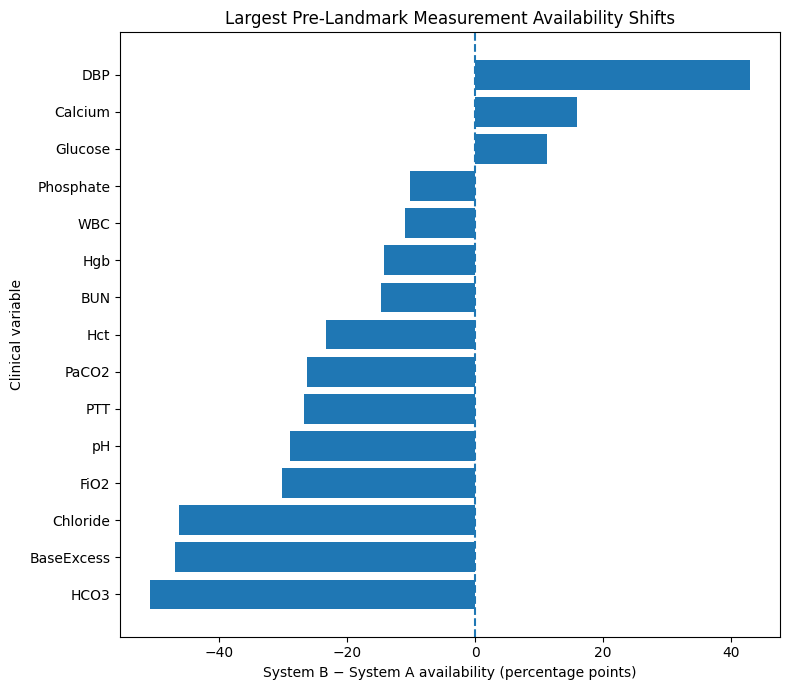

Saved availability-shift figure:
figures/system_a_b_availability_shift.png


In [5]:
import matplotlib.pyplot as plt


top_availability_shift = (
    availability_shift
    .head(15)
    .sort_values(
        "absolute_difference"
    )
)


fig, ax = plt.subplots(
    figsize=(8, 7)
)

ax.barh(
    top_availability_shift[
        "feature"
    ],
    top_availability_shift[
        "absolute_percentage_point_difference"
    ],
)

ax.axvline(
    0,
    linestyle="--",
)

ax.set_xlabel(
    "System B − System A availability "
    "(percentage points)"
)

ax.set_ylabel(
    "Clinical variable"
)

ax.set_title(
    "Largest Pre-Landmark Measurement "
    "Availability Shifts"
)

plt.tight_layout()


AVAILABILITY_SHIFT_FIGURE_DIR = (
    ROOT
    / "figures"
)

AVAILABILITY_SHIFT_FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

AVAILABILITY_SHIFT_FIGURE_PATH = (
    AVAILABILITY_SHIFT_FIGURE_DIR
    / "system_a_b_availability_shift.png"
)


fig.savefig(
    AVAILABILITY_SHIFT_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)


plt.show()


print(
    f"Saved availability-shift figure:\n"
    f"{AVAILABILITY_SHIFT_FIGURE_PATH.relative_to(ROOT)}"
)

## 5. Observed Clinical-Value Distribution Shift

Availability differences characterize whether a variable is measured.

This section asks a distinct question:

> conditional on a frozen predictor having an observed value, does its
> numerical distribution also differ between Health Systems A and B?

To avoid over-weighting repeated summaries of the same vital sign,
the primary descriptive comparison uses:

- static continuous variables;
- the last observed value for each retained vital sign;
- the last observed value for each retained laboratory variable.

For each frozen value feature, cross-system shift is summarized using:

- median in System A;
- median in System B;
- standardized mean difference;
- Kolmogorov-Smirnov statistic.

These analyses are descriptive and do not establish causal mechanisms.

In [6]:
from scipy.stats import ks_2samp


# ---------------------------------------------------------
# Representative value features
# ---------------------------------------------------------

static_value_features = [
    col
    for col in [
        "Age",
        "HospAdmTime",
    ]
    if col in feature_columns
]


vital_last_features = [
    col
    for col in feature_columns
    if (
        col.endswith("__last")
        and col.replace(
            "__last",
            "__mean",
        ) in feature_columns
    )
]


lab_last_features = [
    col
    for col in feature_columns
    if (
        col.endswith("__last")
        and col not in vital_last_features
    )
]


representative_value_features = (
    static_value_features
    + vital_last_features
    + lab_last_features
)


print(
    f"Static continuous variables: "
    f"{len(static_value_features)}"
)

print(
    f"Vital last-value variables: "
    f"{len(vital_last_features)}"
)

print(
    f"Laboratory last-value variables: "
    f"{len(lab_last_features)}"
)

print(
    f"Representative value features: "
    f"{len(representative_value_features)}"
)

Static continuous variables: 2
Vital last-value variables: 7
Laboratory last-value variables: 22
Representative value features: 31


In [7]:
value_shift_records = []


for feature in representative_value_features:

    values_a = (
        system_a[
            feature
        ]
        .dropna()
        .astype(float)
    )

    values_b = (
        system_b[
            feature
        ]
        .dropna()
        .astype(float)
    )


    mean_a = float(
        values_a.mean()
    )

    mean_b = float(
        values_b.mean()
    )

    sd_a = float(
        values_a.std(
            ddof=1
        )
    )

    sd_b = float(
        values_b.std(
            ddof=1
        )
    )


    pooled_sd = np.sqrt(
        (
            sd_a ** 2
            + sd_b ** 2
        )
        / 2
    )


    standardized_mean_difference = (
        (mean_b - mean_a)
        / pooled_sd
        if pooled_sd > 0
        else np.nan
    )


    ks_result = ks_2samp(
        values_a,
        values_b,
        alternative="two-sided",
        method="auto",
    )


    value_shift_records.append(
        {
            "feature":
                feature,

            "n_observed_system_a":
                len(values_a),

            "n_observed_system_b":
                len(values_b),

            "median_system_a":
                float(
                    values_a.median()
                ),

            "median_system_b":
                float(
                    values_b.median()
                ),

            "mean_system_a":
                mean_a,

            "mean_system_b":
                mean_b,

            "standardized_mean_difference":
                standardized_mean_difference,

            "absolute_smd":
                abs(
                    standardized_mean_difference
                ),

            "ks_statistic":
                float(
                    ks_result.statistic
                ),
        }
    )


value_shift = pd.DataFrame(
    value_shift_records
)


value_shift = (
    value_shift
    .sort_values(
        [
            "absolute_smd",
            "ks_statistic",
        ],
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)


value_shift.head(15)

,feature,n_observed_system_a,n_observed_system_b,median_system_a,median_system_b,mean_system_a,mean_system_b,standardized_mean_difference,absolute_smd,ks_statistic
0,Calcium__last,5850,8499,8.3,8.20,8.317667,6.537710,-0.730223,0.730223,0.293995
1,SaO2__last,4337,3108,97.0,97.90,90.484586,97.075434,0.709088,0.709088,0.327539
2,BaseExcess__last,8994,211,-1.0,-2.70,-0.931037,-3.067062,-0.522262,0.522262,0.305894
3,MAP__last,18638,17531,77.0,84.00,78.390606,86.337317,0.508369,0.508369,0.206408
4,DBP__last,10525,17842,59.5,65.00,60.694181,66.579098,0.454643,0.454643,0.186617
5,SBP__last,17780,17844,116.0,123.00,118.822305,125.766541,0.307656,0.307656,0.132186
6,Alkalinephos__last,2005,3618,81.0,69.00,114.080549,87.544500,-0.217857,0.217857,0.139310
7,WBC__last,8830,6531,11.4,9.70,12.624946,10.958895,-0.176428,0.176428,0.155389
8,FiO2__last,9359,3576,0.5,0.40,0.547568,0.512620,-0.169623,0.169623,0.229531
9,Creatinine__last,8706,6775,0.9,0.98,1.317057,1.636275,0.166191,0.166191,0.148266


### Robust Review of Large Observed-Value Shifts

Standardized mean differences can be sensitive to skewed distributions
and extreme observations.

The largest apparent value shifts are therefore reviewed using robust
distribution summaries before they are interpreted.

For the ten features with the largest absolute standardized mean
differences, the following quantities are compared across systems:

- minimum;
- 1st percentile;
- 5th percentile;
- median;
- 95th percentile;
- 99th percentile;
- maximum.

This review distinguishes broad distributional shifts from differences
driven primarily by distribution tails or rare extreme values.

In [8]:
top_shift_features = (
    value_shift
    .head(10)[
        "feature"
    ]
    .tolist()
)


quantile_audit_records = []


for feature in top_shift_features:

    for (
        system_name,
        dataframe,
    ) in [
        ("A", system_a),
        ("B", system_b),
    ]:

        values = (
            dataframe[
                feature
            ]
            .dropna()
            .astype(float)
        )

        quantile_audit_records.append(
            {
                "feature":
                    feature,

                "system":
                    system_name,

                "n_observed":
                    len(values),

                "minimum":
                    float(
                        values.min()
                    ),

                "p01":
                    float(
                        values.quantile(
                            0.01
                        )
                    ),

                "p05":
                    float(
                        values.quantile(
                            0.05
                        )
                    ),

                "median":
                    float(
                        values.median()
                    ),

                "p95":
                    float(
                        values.quantile(
                            0.95
                        )
                    ),

                "p99":
                    float(
                        values.quantile(
                            0.99
                        )
                    ),

                "maximum":
                    float(
                        values.max()
                    ),
            }
        )


value_shift_quantile_audit = pd.DataFrame(
    quantile_audit_records
)


value_shift_quantile_audit

,feature,system,n_observed,minimum,p01,p05,median,p95,p99,maximum
0,Calcium__last,A,5850,4.70,6.1490,6.900,8.30,9.700,11.0000,17.5
1,Calcium__last,B,8499,1.00,1.0400,1.110,8.20,9.500,10.4000,20.6
2,SaO2__last,A,4337,24.00,51.0000,62.000,97.00,99.000,99.0000,100.0
3,SaO2__last,B,3108,45.20,85.8210,92.235,97.90,99.600,99.9000,100.0
4,BaseExcess__last,A,8994,-25.00,-12.0000,-7.000,-1.00,6.000,11.0000,36.0
5,BaseExcess__last,B,211,-23.20,-16.1100,-9.800,-2.70,2.800,5.2700,9.0
6,MAP__last,A,18638,20.00,51.0000,58.000,77.00,104.000,119.2079,250.0
7,MAP__last,B,17531,31.00,55.0000,63.000,84.00,116.000,133.0000,231.5
8,DBP__last,A,10525,23.00,37.0000,44.000,59.50,81.000,95.0000,183.0
9,DBP__last,B,17842,20.00,39.0000,47.000,65.00,91.000,105.0000,168.0


### Targeted Review of Calcium Scale Heterogeneity

The System B calcium distribution shows a distinct low-value tail that
is not present in System A.

Because the System B median remains similar to System A while the lower
quantiles cluster near approximately 1, this pattern may reflect
measurement-definition or unit heterogeneity rather than a simple shift
in patient physiology.

This audit is descriptive only.

The frozen System A model and System B predictions are not modified based
on this post-validation investigation.

In [9]:
calcium_scale_summary = []

for (
    system_name,
    dataframe,
) in [
    ("A", system_a),
    ("B", system_b),
]:

    calcium = (
        dataframe[
            "Calcium__last"
        ]
        .dropna()
        .astype(float)
    )

    calcium_scale_summary.append(
        {
            "system":
                system_name,

            "n_observed":
                len(calcium),

            "n_below_2":
                int(
                    (calcium < 2).sum()
                ),

            "pct_below_2":
                float(
                    (calcium < 2).mean()
                    * 100
                ),

            "n_2_to_4":
                int(
                    (
                        (calcium >= 2)
                        & (calcium < 4)
                    ).sum()
                ),

            "pct_2_to_4":
                float(
                    (
                        (calcium >= 2)
                        & (calcium < 4)
                    ).mean()
                    * 100
                ),

            "n_4_or_above":
                int(
                    (calcium >= 4).sum()
                ),

            "pct_4_or_above":
                float(
                    (calcium >= 4).mean()
                    * 100
                ),
        }
    )


calcium_scale_audit = pd.DataFrame(
    calcium_scale_summary
)

calcium_scale_audit

,system,n_observed,n_below_2,pct_below_2,n_2_to_4,pct_2_to_4,n_4_or_above,pct_4_or_above
0,A,5850,0,0.000000,0,0.000000,5850,100.000000
1,B,8499,2143,25.214731,21,0.247088,6335,74.538181


In [10]:
system_b_low_calcium = (
    system_b.loc[
        system_b[
            "Calcium__last"
        ] < 2,
        [
            "patient_id",
            "Calcium__last",
            "Calcium__available",
            "Creatinine__last",
            "Phosphate__last",
            "Magnesium__last",
        ],
    ]
    .sort_values(
        "Calcium__last"
    )
)

print(
    f"System B patients with Calcium < 2: "
    f"{len(system_b_low_calcium):,}"
)

system_b_low_calcium.head(20)

System B patients with Calcium < 2: 2,143


,patient_id,Calcium__last,Calcium__available,Creatinine__last,Phosphate__last,Magnesium__last
9090,p110116,1.00,1,0.71,1.2,1.8
11987,p113324,1.00,1,NaN,NaN,NaN
15657,p117422,1.00,1,NaN,NaN,NaN
15735,p117509,1.00,1,0.96,2.6,1.7
3299,p103698,1.00,1,NaN,NaN,NaN
13215,p114689,1.00,1,NaN,NaN,NaN
2588,p102899,1.00,1,4.24,6.9,1.3
11341,p112606,1.00,1,NaN,NaN,NaN
5095,p105684,1.00,1,NaN,NaN,NaN
13518,p115024,1.00,1,7.83,3.4,1.9


### Calcium Scale Audit Interpretation

A distinct calcium measurement regime is present in Health System B.

Among patients with an observed pre-landmark calcium value, 25.2% of
System B patients have a last value below 2, compared with none in
System A. Many of these System B values cluster near approximately 1.0.

Because the official Challenge variable specification describes calcium
in mg/dL, this pattern is treated as suspected cross-system
measurement-definition or scale heterogeneity rather than ordinary
physiologic distribution shift.

The exact source of the discrepancy cannot be established from the
released data alone.

No calcium values are modified retrospectively, and the locked external
validation results remain unchanged.

## 6. Pre-Landmark Measurement-Intensity Shift

Feature availability captures whether a variable was measured at least
once before the landmark, but it does not capture how frequently the
variable was measured.

Measurement frequency may reflect monitoring intensity, clinical
workflow, illness severity, or health-system-specific practice.

For each retained longitudinal variable, the number of recorded
measurements up to and including ICU hour 6 is reconstructed directly
from the raw records.

Measurement counts are analyzed descriptively only and were not used as
predictors in the frozen primary models.

In [11]:
A_DIR = (
    ROOT
    / "data"
    / "raw"
    / "training"
    / "training_setA"
)

B_DIR = (
    ROOT
    / "data"
    / "raw"
    / "training"
    / "training_setB"
)


files_a = sorted(
    A_DIR.glob("*.psv")
)

files_b = sorted(
    B_DIR.glob("*.psv")
)


analysis_ids_a = set(
    system_a[
        "patient_id"
    ]
)

analysis_ids_b = set(
    system_b[
        "patient_id"
    ]
)


longitudinal_variables = sorted(
    {
        col.removesuffix(
            "__available"
        )
        for col in availability_columns
    }
)


print(
    f"System A eligible patients: "
    f"{len(analysis_ids_a):,}"
)

print(
    f"System B eligible patients: "
    f"{len(analysis_ids_b):,}"
)

print(
    f"Longitudinal variables: "
    f"{len(longitudinal_variables)}"
)


assert len(
    longitudinal_variables
) == 29

System A eligible patients: 18,699
System B eligible patients: 17,982
Longitudinal variables: 29


In [12]:
def build_measurement_count_matrix(
    files,
    analysis_ids,
    system_name,
):
    records = []

    for path in files:
        patient_id = path.stem

        if patient_id not in analysis_ids:
            continue

        df = pd.read_csv(
            path,
            sep="|",
        )

        pre = df.loc[
            df["ICULOS"] <= 6
        ]

        record = {
            "patient_id":
                patient_id,

            "system":
                system_name,

            "n_pre_landmark_rows":
                len(pre),
        }

        for feature in (
            longitudinal_variables
        ):
            record[
                f"{feature}__n_observed"
            ] = int(
                pre[
                    feature
                ]
                .notna()
                .sum()
            )

        records.append(
            record
        )

    return pd.DataFrame(
        records
    )


measurement_counts_a = (
    build_measurement_count_matrix(
        files_a,
        analysis_ids_a,
        "A",
    )
)

measurement_counts_b = (
    build_measurement_count_matrix(
        files_b,
        analysis_ids_b,
        "B",
    )
)


print(
    f"System A count records: "
    f"{len(measurement_counts_a):,}"
)

print(
    f"System B count records: "
    f"{len(measurement_counts_b):,}"
)


assert len(
    measurement_counts_a
) == 18_699

assert len(
    measurement_counts_b
) == 17_982

System A count records: 18,699
System B count records: 17,982


In [13]:
measurement_intensity_records = []


for feature in longitudinal_variables:

    count_col = (
        f"{feature}__n_observed"
    )

    counts_a = (
        measurement_counts_a[
            count_col
        ]
    )

    counts_b = (
        measurement_counts_b[
            count_col
        ]
    )

    available_a = counts_a[
        counts_a > 0
    ]

    available_b = counts_b[
        counts_b > 0
    ]


    measurement_intensity_records.append(
        {
            "feature":
                feature,

            "median_count_if_available_a":
                float(
                    available_a.median()
                )
                if len(available_a) > 0
                else np.nan,

            "median_count_if_available_b":
                float(
                    available_b.median()
                )
                if len(available_b) > 0
                else np.nan,

            "mean_count_if_available_a":
                float(
                    available_a.mean()
                )
                if len(available_a) > 0
                else np.nan,

            "mean_count_if_available_b":
                float(
                    available_b.mean()
                )
                if len(available_b) > 0
                else np.nan,

            "delta_mean_count_if_available":
                (
                    float(
                        available_b.mean()
                    )
                    -
                    float(
                        available_a.mean()
                    )
                )
                if (
                    len(available_a) > 0
                    and len(available_b) > 0
                )
                else np.nan,
        }
    )


measurement_intensity_shift = pd.DataFrame(
    measurement_intensity_records
)


measurement_intensity_shift[
    "absolute_delta_mean_count"
] = (
    measurement_intensity_shift[
        "delta_mean_count_if_available"
    ].abs()
)


measurement_intensity_shift = (
    measurement_intensity_shift
    .sort_values(
        "absolute_delta_mean_count",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)


measurement_intensity_shift.head(15)

,feature,median_count_if_available_a,median_count_if_available_b,mean_count_if_available_a,mean_count_if_available_b,delta_mean_count_if_available,absolute_delta_mean_count
0,FiO2,2.0,1.0,2.100321,1.441776,-0.658544,0.658544
1,HCO3,1.0,1.0,1.199378,1.792453,0.593075,0.593075
2,pH,2.0,1.0,1.940525,1.428181,-0.512344,0.512344
3,DBP,5.0,5.0,4.012067,4.524381,0.512314,0.512314
4,Glucose,1.0,1.0,1.466065,1.881495,0.415430,0.415430
5,Hct,1.0,1.0,1.381472,1.086762,-0.294710,0.294710
6,PaCO2,1.0,1.0,1.688468,1.427831,-0.260637,0.260637
7,SaO2,1.0,1.0,1.647452,1.426641,-0.220811,0.220811
8,Hgb,1.0,1.0,1.297068,1.076989,-0.220078,0.220078
9,Resp,5.0,5.0,4.409977,4.222935,-0.187043,0.187043


### Pre-Landmark Observation-History Comparison

Measurement counts depend partly on how much patient history is observed
before the landmark.

Before interpreting differences in measurement intensity as health-system
workflow differences, the amount of available pre-landmark observation
history is compared between Systems A and B.

The number of observed rows up to and including ICU hour 6 is therefore
summarized separately for each system.

In [14]:
pre_landmark_history_summary = pd.DataFrame(
    [
        {
            "system": "A",

            "patients":
                len(
                    measurement_counts_a
                ),

            "mean_rows":
                float(
                    measurement_counts_a[
                        "n_pre_landmark_rows"
                    ].mean()
                ),

            "std_rows":
                float(
                    measurement_counts_a[
                        "n_pre_landmark_rows"
                    ].std()
                ),

            "minimum":
                int(
                    measurement_counts_a[
                        "n_pre_landmark_rows"
                    ].min()
                ),

            "p05":
                float(
                    measurement_counts_a[
                        "n_pre_landmark_rows"
                    ].quantile(
                        0.05
                    )
                ),

            "p25":
                float(
                    measurement_counts_a[
                        "n_pre_landmark_rows"
                    ].quantile(
                        0.25
                    )
                ),

            "median":
                float(
                    measurement_counts_a[
                        "n_pre_landmark_rows"
                    ].median()
                ),

            "p75":
                float(
                    measurement_counts_a[
                        "n_pre_landmark_rows"
                    ].quantile(
                        0.75
                    )
                ),

            "p95":
                float(
                    measurement_counts_a[
                        "n_pre_landmark_rows"
                    ].quantile(
                        0.95
                    )
                ),

            "maximum":
                int(
                    measurement_counts_a[
                        "n_pre_landmark_rows"
                    ].max()
                ),
        },

        {
            "system": "B",

            "patients":
                len(
                    measurement_counts_b
                ),

            "mean_rows":
                float(
                    measurement_counts_b[
                        "n_pre_landmark_rows"
                    ].mean()
                ),

            "std_rows":
                float(
                    measurement_counts_b[
                        "n_pre_landmark_rows"
                    ].std()
                ),

            "minimum":
                int(
                    measurement_counts_b[
                        "n_pre_landmark_rows"
                    ].min()
                ),

            "p05":
                float(
                    measurement_counts_b[
                        "n_pre_landmark_rows"
                    ].quantile(
                        0.05
                    )
                ),

            "p25":
                float(
                    measurement_counts_b[
                        "n_pre_landmark_rows"
                    ].quantile(
                        0.25
                    )
                ),

            "median":
                float(
                    measurement_counts_b[
                        "n_pre_landmark_rows"
                    ].median()
                ),

            "p75":
                float(
                    measurement_counts_b[
                        "n_pre_landmark_rows"
                    ].quantile(
                        0.75
                    )
                ),

            "p95":
                float(
                    measurement_counts_b[
                        "n_pre_landmark_rows"
                    ].quantile(
                        0.95
                    )
                ),

            "maximum":
                int(
                    measurement_counts_b[
                        "n_pre_landmark_rows"
                    ].max()
                ),
        },
    ]
)

pre_landmark_history_summary

,system,patients,mean_rows,std_rows,minimum,p05,p25,median,p75,p95,maximum
0,A,18699,5.284079,1.196471,1,3.0,5.0,6.0,6.0,6.0,6
1,B,17982,5.895840,0.499146,1,5.0,6.0,6.0,6.0,6.0,6


In [15]:
pre_landmark_row_distribution = pd.concat(
    [
        (
            measurement_counts_a[
                "n_pre_landmark_rows"
            ]
            .value_counts(
                normalize=True
            )
            .rename(
                "system_a_proportion"
            )
        ),

        (
            measurement_counts_b[
                "n_pre_landmark_rows"
            ]
            .value_counts(
                normalize=True
            )
            .rename(
                "system_b_proportion"
            )
        ),
    ],
    axis=1,
).fillna(0)


pre_landmark_row_distribution[
    "difference_b_minus_a"
] = (
    pre_landmark_row_distribution[
        "system_b_proportion"
    ]
    -
    pre_landmark_row_distribution[
        "system_a_proportion"
    ]
)


pre_landmark_row_distribution = (
    pre_landmark_row_distribution
    .sort_index()
)

pre_landmark_row_distribution

,system_a_proportion,system_b_proportion,difference_b_minus_a
n_pre_landmark_rows,,,
1,0.019145,0.002781,-0.016365
2,0.030055,0.003504,-0.026552
3,0.051928,0.006395,-0.045533
4,0.086475,0.009899,-0.076576
5,0.171239,0.037259,-0.133980
6,0.641157,0.940162,0.299005


### Observation-Time-Normalized Measurement Intensity

The amount of available pre-landmark history differs substantially
between the two health systems.

System B patients more frequently have the full six observed
pre-landmark rows, so raw measurement counts are not directly comparable
across systems.

Measurement intensity is therefore normalized by each patient's number
of available pre-landmark rows.

For each retained longitudinal variable, the patient-level measurement
density is defined as:

`number of observed measurements / number of pre-landmark rows`

The primary comparison below is conditional on the variable being
measured at least once, separating measurement frequency from the
availability shift analyzed previously.

In [16]:
normalized_intensity_records = []


for feature in longitudinal_variables:

    count_col = (
        f"{feature}__n_observed"
    )


    # ---------------------------------------------------------
    # Patient-level measurement density
    # ---------------------------------------------------------

    density_a = (
        measurement_counts_a[
            count_col
        ]
        /
        measurement_counts_a[
            "n_pre_landmark_rows"
        ]
    )

    density_b = (
        measurement_counts_b[
            count_col
        ]
        /
        measurement_counts_b[
            "n_pre_landmark_rows"
        ]
    )


    # ---------------------------------------------------------
    # Restrict to patients with at least one measurement
    # ---------------------------------------------------------

    available_mask_a = (
        measurement_counts_a[
            count_col
        ]
        > 0
    )

    available_mask_b = (
        measurement_counts_b[
            count_col
        ]
        > 0
    )


    available_density_a = density_a.loc[
        available_mask_a
    ]

    available_density_b = density_b.loc[
        available_mask_b
    ]


    normalized_intensity_records.append(
        {
            "feature":
                feature,

            "mean_density_if_available_a":
                float(
                    available_density_a.mean()
                ),

            "mean_density_if_available_b":
                float(
                    available_density_b.mean()
                ),

            "median_density_if_available_a":
                float(
                    available_density_a.median()
                ),

            "median_density_if_available_b":
                float(
                    available_density_b.median()
                ),

            "delta_mean_density_b_minus_a":
                float(
                    available_density_b.mean()
                    -
                    available_density_a.mean()
                ),
        }
    )


normalized_measurement_intensity = pd.DataFrame(
    normalized_intensity_records
)


normalized_measurement_intensity[
    "absolute_delta_mean_density"
] = (
    normalized_measurement_intensity[
        "delta_mean_density_b_minus_a"
    ].abs()
)


normalized_measurement_intensity = (
    normalized_measurement_intensity
    .sort_values(
        "absolute_delta_mean_density",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)


normalized_measurement_intensity.head(15)

,feature,mean_density_if_available_a,mean_density_if_available_b,median_density_if_available_a,median_density_if_available_b,delta_mean_density_b_minus_a,absolute_delta_mean_density
0,FiO2,0.467263,0.256683,0.400000,0.166667,-0.210580,0.210580
1,pH,0.440288,0.255084,0.333333,0.166667,-0.185205,0.185205
2,Resp,0.851842,0.716345,0.833333,0.833333,-0.135497,0.135497
3,PaCO2,0.383201,0.255239,0.333333,0.166667,-0.127963,0.127963
4,SaO2,0.379986,0.252322,0.333333,0.166667,-0.127664,0.127664
5,Hct,0.307947,0.187306,0.200000,0.166667,-0.120641,0.120641
6,Hgb,0.294668,0.185636,0.200000,0.166667,-0.109032,0.109032
7,BaseExcess,0.440610,0.335229,0.333333,0.250000,-0.105381,0.105381
8,WBC,0.273843,0.179406,0.200000,0.166667,-0.094437,0.094437
9,BUN,0.269713,0.179317,0.200000,0.166667,-0.090396,0.090396


## 7. Static and Care-Context Shift

Cross-system differences may also reflect changes in patient mix and
care context rather than longitudinal measurement behavior alone.

This section compares the frozen static and contextual variables:

- age;
- gender;
- hospital-admission timing relative to ICU admission;
- ICU-unit category.

Continuous variables are summarized descriptively, while categorical
variables are compared using patient proportions.

These comparisons are diagnostic and are not used to modify the frozen
prediction models.

In [17]:
static_continuous_shift = pd.DataFrame(
    [
        {
            "feature": "Age",

            "median_system_a":
                float(
                    system_a[
                        "Age"
                    ].median()
                ),

            "median_system_b":
                float(
                    system_b[
                        "Age"
                    ].median()
                ),

            "mean_system_a":
                float(
                    system_a[
                        "Age"
                    ].mean()
                ),

            "mean_system_b":
                float(
                    system_b[
                        "Age"
                    ].mean()
                ),
        },

        {
            "feature": "HospAdmTime",

            "median_system_a":
                float(
                    system_a[
                        "HospAdmTime"
                    ].median()
                ),

            "median_system_b":
                float(
                    system_b[
                        "HospAdmTime"
                    ].median()
                ),

            "mean_system_a":
                float(
                    system_a[
                        "HospAdmTime"
                    ].mean()
                ),

            "mean_system_b":
                float(
                    system_b[
                        "HospAdmTime"
                    ].mean()
                ),
        },
    ]
)


for row_index in static_continuous_shift.index:

    feature = static_continuous_shift.loc[
        row_index,
        "feature",
    ]

    values_a = system_a[
        feature
    ].dropna()

    values_b = system_b[
        feature
    ].dropna()

    sd_a = values_a.std(
        ddof=1
    )

    sd_b = values_b.std(
        ddof=1
    )

    pooled_sd = np.sqrt(
        (
            sd_a ** 2
            + sd_b ** 2
        )
        / 2
    )

    static_continuous_shift.loc[
        row_index,
        "standardized_mean_difference",
    ] = (
        (
            values_b.mean()
            - values_a.mean()
        )
        / pooled_sd
    )


static_continuous_shift

,feature,median_system_a,median_system_b,mean_system_a,mean_system_b,standardized_mean_difference
0,Age,64.85,62.000,62.751504,60.926983,-0.111386
1,HospAdmTime,-2.82,-8.935,-47.913943,-56.386939,-0.061321


In [18]:
static_categorical_shift = pd.DataFrame(
    [
        {
            "category":
                "Gender = 1",

            "proportion_system_a":
                float(
                    system_a[
                        "Gender"
                    ].mean()
                ),

            "proportion_system_b":
                float(
                    system_b[
                        "Gender"
                    ].mean()
                ),
        },

        {
            "category":
                "ICU Unit1",

            "proportion_system_a":
                float(
                    system_a[
                        "ICU_unit_Unit1"
                    ].mean()
                ),

            "proportion_system_b":
                float(
                    system_b[
                        "ICU_unit_Unit1"
                    ].mean()
                ),
        },

        {
            "category":
                "ICU Unit2",

            "proportion_system_a":
                float(
                    system_a[
                        "ICU_unit_Unit2"
                    ].mean()
                ),

            "proportion_system_b":
                float(
                    system_b[
                        "ICU_unit_Unit2"
                    ].mean()
                ),
        },

        {
            "category":
                "ICU Unit Unknown",

            "proportion_system_a":
                float(
                    (
                        (
                            system_a[
                                "ICU_unit_Unit1"
                            ] == 0
                        )
                        &
                        (
                            system_a[
                                "ICU_unit_Unit2"
                            ] == 0
                        )
                    ).mean()
                ),

            "proportion_system_b":
                float(
                    (
                        (
                            system_b[
                                "ICU_unit_Unit1"
                            ] == 0
                        )
                        &
                        (
                            system_b[
                                "ICU_unit_Unit2"
                            ] == 0
                        )
                    ).mean()
                ),
        },
    ]
)


static_categorical_shift[
    "difference_b_minus_a"
] = (
    static_categorical_shift[
        "proportion_system_b"
    ]
    -
    static_categorical_shift[
        "proportion_system_a"
    ]
)


static_categorical_shift[
    "percentage_point_difference"
] = (
    100
    * static_categorical_shift[
        "difference_b_minus_a"
    ]
)


static_categorical_shift

,category,proportion_system_a,proportion_system_b,difference_b_minus_a,percentage_point_difference
0,Gender = 1,0.580940,0.539929,-0.041011,-4.101134
1,ICU Unit1,0.260281,0.344456,0.084174,8.417427
2,ICU Unit2,0.268838,0.359137,0.090299,9.029901
3,ICU Unit Unknown,0.470881,0.296408,-0.174473,-17.447328


## 8. Health-System Domain Classification

A domain classifier is used as an integrated summary of cross-system
distribution shift.

The task is deliberately different from the sepsis prediction task:

- outcome = Health System A or Health System B;
- predictors = frozen patient-level variables available at ICU hour 6.

If patients from the two systems cannot be distinguished from their
features, domain-classification AUROC should be near 0.5.

Higher AUROC indicates stronger multivariable separation between the
health systems.

Three complementary diagnostic representations are compared:

1. availability indicators only;
2. observed-value features without availability indicators;
3. the complete frozen 84-feature representation.

This post-validation analysis is descriptive and is not used to modify
the frozen sepsis models.

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


domain_a = (
    system_a[
        ["patient_id"]
        + feature_columns
    ]
    .copy()
)

domain_a[
    "system_label"
] = 0


domain_b = (
    system_b[
        ["patient_id"]
        + feature_columns
    ]
    .copy()
)

domain_b[
    "system_label"
] = 1


domain_data = pd.concat(
    [
        domain_a,
        domain_b,
    ],
    ignore_index=True,
)


domain_y = (
    domain_data[
        "system_label"
    ]
    .astype(int)
    .to_numpy()
)


availability_domain_features = [
    col
    for col in feature_columns
    if col.endswith(
        "__available"
    )
]


value_domain_features = [
    col
    for col in feature_columns
    if col not in availability_domain_features
]


print(
    f"Domain-classification patients: "
    f"{len(domain_data):,}"
)

print(
    f"Availability-only features: "
    f"{len(availability_domain_features)}"
)

print(
    f"Value/context features: "
    f"{len(value_domain_features)}"
)

print(
    f"Full frozen features: "
    f"{len(feature_columns)}"
)


assert len(domain_data) == (
    18_699
    + 17_982
)

assert len(
    availability_domain_features
) == 29

assert len(
    value_domain_features
) == 55

assert len(
    feature_columns
) == 84

Domain-classification patients: 36,681
Availability-only features: 29
Value/context features: 55
Full frozen features: 84


In [20]:
DOMAIN_RANDOM_STATE = 20260919
DOMAIN_CV_FOLDS = 5


domain_cv = StratifiedKFold(
    n_splits=DOMAIN_CV_FOLDS,
    shuffle=True,
    random_state=DOMAIN_RANDOM_STATE,
)


def build_domain_pipeline(
    selected_features
):
    continuous_features = [
        col
        for col in selected_features
        if col not in binary_feature_columns
    ]

    binary_features = [
        col
        for col in selected_features
        if col in binary_feature_columns
    ]


    transformers = []


    if len(
        continuous_features
    ) > 0:
        continuous_pipeline = Pipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(
                        strategy="median"
                    ),
                ),
                (
                    "scaler",
                    StandardScaler(),
                ),
            ]
        )

        transformers.append(
            (
                "continuous",
                continuous_pipeline,
                continuous_features,
            )
        )


    if len(
        binary_features
    ) > 0:
        binary_pipeline = Pipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(
                        strategy="most_frequent"
                    ),
                ),
            ]
        )

        transformers.append(
            (
                "binary",
                binary_pipeline,
                binary_features,
            )
        )


    preprocessing = ColumnTransformer(
        transformers=transformers,
        remainder="drop",
    )


    classifier = LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="lbfgs",
        max_iter=5000,
    )


    pipeline = Pipeline(
        steps=[
            (
                "preprocessing",
                preprocessing,
            ),
            (
                "classifier",
                classifier,
            ),
        ]
    )


    return pipeline

In [21]:
domain_feature_sets = {
    "Availability indicators only":
        availability_domain_features,

    "Observed values and context":
        value_domain_features,

    "Full frozen representation":
        feature_columns,
}


domain_classifier_records = []

domain_oof_predictions = {}


for (
    representation_name,
    selected_features,
) in domain_feature_sets.items():

    print(
        f"Running domain classifier: "
        f"{representation_name}"
    )

    pipeline = build_domain_pipeline(
        selected_features
    )

    probabilities = cross_val_predict(
        pipeline,
        domain_data[
            selected_features
        ],
        domain_y,
        cv=domain_cv,
        method="predict_proba",
        n_jobs=-1,
    )[:, 1]


    domain_oof_predictions[
        representation_name
    ] = probabilities


    domain_classifier_records.append(
        {
            "representation":
                representation_name,

            "n_features":
                len(
                    selected_features
                ),

            "AUROC":
                roc_auc_score(
                    domain_y,
                    probabilities,
                ),

            "mean_predicted_probability":
                float(
                    probabilities.mean()
                ),

            "observed_system_b_fraction":
                float(
                    domain_y.mean()
                ),
        }
    )


domain_classifier_summary = pd.DataFrame(
    domain_classifier_records
)

domain_classifier_summary

Running domain classifier: Availability indicators only
Running domain classifier: Observed values and context
Running domain classifier: Full frozen representation


,representation,n_features,AUROC,mean_predicted_probability,observed_system_b_fraction
0,Availability indicators only,29,0.987759,0.490261,0.490227
1,Observed values and context,55,0.819121,0.490274,0.490227
2,Full frozen representation,84,0.994076,0.490293,0.490227


### High-Coverage Domain Classification Sensitivity Analysis

The value/context domain classifier above uses fold-wise median
imputation and may therefore retain some residual information about
missingness patterns.

As a post-validation sensitivity analysis, domain classification is
repeated using only longitudinal variables with at least 90%
patient-level availability in both health systems, together with frozen
static and care-context variables.

The 90% threshold is used only for this diagnostic sensitivity analysis
and does not alter the frozen prediction models or primary external
validation.

This representation substantially reduces dependence on differential
missingness and provides a more conservative assessment of patient-mix
and clinical-value separation across systems.

In [22]:
high_coverage_variables = (
    availability_shift.loc[
        (
            availability_shift[
                "availability_system_a"
            ] >= 0.90
        )
        &
        (
            availability_shift[
                "availability_system_b"
            ] >= 0.90
        ),
        "feature",
    ]
    .tolist()
)


high_coverage_feature_columns = [
    col
    for col in feature_columns
    if any(
        col.startswith(
            f"{feature}__"
        )
        for feature in high_coverage_variables
    )
]


static_context_features = [
    "Age",
    "Gender",
    "HospAdmTime",
    "ICU_unit_Unit1",
    "ICU_unit_Unit2",
]


high_coverage_domain_features = (
    static_context_features
    + high_coverage_feature_columns
)


print(
    "High-coverage longitudinal variables:"
)

print(
    high_coverage_variables
)

print(
    f"\nHigh-coverage longitudinal variables: "
    f"{len(high_coverage_variables)}"
)

print(
    f"Domain features including static/context: "
    f"{len(high_coverage_domain_features)}"
)

High-coverage longitudinal variables:
['SBP', 'Resp', 'MAP', 'HR', 'O2Sat']

High-coverage longitudinal variables: 5
Domain features including static/context: 30


In [23]:
high_coverage_domain_pipeline = (
    build_domain_pipeline(
        high_coverage_domain_features
    )
)


high_coverage_domain_probability = (
    cross_val_predict(
        high_coverage_domain_pipeline,
        domain_data[
            high_coverage_domain_features
        ],
        domain_y,
        cv=domain_cv,
        method="predict_proba",
        n_jobs=-1,
    )[:, 1]
)


high_coverage_domain_summary = pd.Series(
    {
        "n_longitudinal_variables":
            len(
                high_coverage_variables
            ),

        "n_model_columns":
            len(
                high_coverage_domain_features
            ),

        "AUROC":
            roc_auc_score(
                domain_y,
                high_coverage_domain_probability,
            ),

        "mean_predicted_probability":
            float(
                high_coverage_domain_probability.mean()
            ),

        "observed_system_b_fraction":
            float(
                domain_y.mean()
            ),
    },
    name="High-coverage domain classifier",
)


high_coverage_domain_summary.to_frame()

,High-coverage domain classifier
n_longitudinal_variables,5.000000
n_model_columns,30.000000
AUROC,0.765566
mean_predicted_probability,0.490234
observed_system_b_fraction,0.490227


### Strict High-Coverage Clinical-Value Sensitivity Analysis

The preceding high-coverage analysis still includes availability
indicators and ICU-unit variables.

A stricter sensitivity analysis therefore removes:

- all availability indicators;
- ICU-unit indicators.

Only high-coverage physiologic summaries and basic demographic /
admission-timing variables are retained.

This analysis provides a more conservative assessment of whether
clinical-value and basic patient-mix differences remain after strongly
reducing explicit measurement-process and care-context information.

In [24]:
strict_high_coverage_value_features = []

for feature in high_coverage_variables:

    for suffix in [
        "__last",
        "__mean",
        "__min",
        "__max",
    ]:
        column = (
            f"{feature}{suffix}"
        )

        if column in feature_columns:
            strict_high_coverage_value_features.append(
                column
            )


strict_basic_context_features = [
    "Age",
    "Gender",
    "HospAdmTime",
]


strict_high_coverage_domain_features = (
    strict_basic_context_features
    + strict_high_coverage_value_features
)


print(
    "Strict high-coverage longitudinal variables:"
)

print(
    high_coverage_variables
)

print(
    f"\nClinical-value summary columns: "
    f"{len(strict_high_coverage_value_features)}"
)

print(
    f"Total strict domain features: "
    f"{len(strict_high_coverage_domain_features)}"
)


assert not any(
    col.endswith("__available")
    for col in strict_high_coverage_domain_features
)

assert (
    "ICU_unit_Unit1"
    not in strict_high_coverage_domain_features
)

assert (
    "ICU_unit_Unit2"
    not in strict_high_coverage_domain_features
)

Strict high-coverage longitudinal variables:
['SBP', 'Resp', 'MAP', 'HR', 'O2Sat']

Clinical-value summary columns: 20
Total strict domain features: 23


In [25]:
strict_high_coverage_pipeline = (
    build_domain_pipeline(
        strict_high_coverage_domain_features
    )
)


strict_high_coverage_probability = (
    cross_val_predict(
        strict_high_coverage_pipeline,
        domain_data[
            strict_high_coverage_domain_features
        ],
        domain_y,
        cv=domain_cv,
        method="predict_proba",
        n_jobs=-1,
    )[:, 1]
)


strict_high_coverage_summary = pd.Series(
    {
        "n_longitudinal_variables":
            len(
                high_coverage_variables
            ),

        "n_model_columns":
            len(
                strict_high_coverage_domain_features
            ),

        "AUROC":
            roc_auc_score(
                domain_y,
                strict_high_coverage_probability,
            ),

        "mean_predicted_probability":
            float(
                strict_high_coverage_probability.mean()
            ),

        "observed_system_b_fraction":
            float(
                domain_y.mean()
            ),
    },
    name=(
        "Strict high-coverage "
        "clinical-value domain classifier"
    ),
)


strict_high_coverage_summary.to_frame()

,Strict high-coverage clinical-value domain classifier
n_longitudinal_variables,5.000000
n_model_columns,23.000000
AUROC,0.705882
mean_predicted_probability,0.490281
observed_system_b_fraction,0.490227


### Domain-Separability Summary

The domain-classification analyses show that the strongest separation
between Health Systems A and B arises from measurement availability.

However, meaningful cross-system separation remains even after explicit
availability indicators and ICU-unit variables are removed.

This suggests that the observed domain shift reflects both:

- differences in measurement / documentation processes; and
- differences in high-coverage clinical-value and basic patient-context
  distributions.

Domain classification quantifies separability between systems and does
not establish that any specific shift causes predictive-performance
degradation.

In [26]:
domain_separability_summary = pd.DataFrame(
    [
        {
            "representation":
                "Availability indicators only",

            "n_features":
                len(
                    availability_domain_features
                ),

            "AUROC":
                float(
                    domain_classifier_summary.loc[
                        domain_classifier_summary[
                            "representation"
                        ]
                        == "Availability indicators only",
                        "AUROC",
                    ].iloc[0]
                ),
        },

        {
            "representation":
                "Observed values and context",

            "n_features":
                len(
                    value_domain_features
                ),

            "AUROC":
                float(
                    domain_classifier_summary.loc[
                        domain_classifier_summary[
                            "representation"
                        ]
                        == "Observed values and context",
                        "AUROC",
                    ].iloc[0]
                ),
        },

        {
            "representation":
                "Full frozen representation",

            "n_features":
                len(
                    feature_columns
                ),

            "AUROC":
                float(
                    domain_classifier_summary.loc[
                        domain_classifier_summary[
                            "representation"
                        ]
                        == "Full frozen representation",
                        "AUROC",
                    ].iloc[0]
                ),
        },

        {
            "representation":
                "High-coverage representation",

            "n_features":
                int(
                    high_coverage_domain_summary[
                        "n_model_columns"
                    ]
                ),

            "AUROC":
                float(
                    high_coverage_domain_summary[
                        "AUROC"
                    ]
                ),
        },

        {
            "representation":
                (
                    "Strict high-coverage "
                    "clinical/basic context"
                ),

            "n_features":
                int(
                    strict_high_coverage_summary[
                        "n_model_columns"
                    ]
                ),

            "AUROC":
                float(
                    strict_high_coverage_summary[
                        "AUROC"
                    ]
                ),
        },
    ]
)


domain_separability_summary

,representation,n_features,AUROC
0,Availability indicators only,29,0.987759
1,Observed values and context,55,0.819121
2,Full frozen representation,84,0.994076
3,High-coverage representation,30,0.765566
4,Strict high-coverage clinical/basic context,23,0.705882


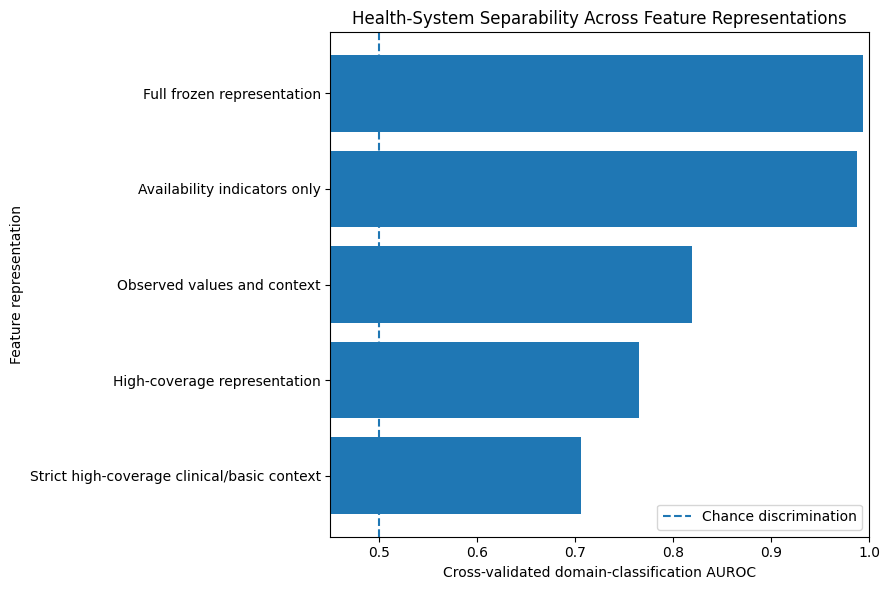

In [27]:
fig, ax = plt.subplots(
    figsize=(9, 6)
)


plot_data = (
    domain_separability_summary
    .sort_values(
        "AUROC"
    )
)


ax.barh(
    plot_data[
        "representation"
    ],
    plot_data[
        "AUROC"
    ],
)


ax.axvline(
    0.5,
    linestyle="--",
    label="Chance discrimination",
)


ax.set_xlim(
    0.45,
    1.0,
)

ax.set_xlabel(
    "Cross-validated domain-classification AUROC"
)

ax.set_ylabel(
    "Feature representation"
)

ax.set_title(
    "Health-System Separability Across Feature Representations"
)

ax.legend()

plt.tight_layout()
plt.show()

## 9. Summary of Cross-System Shift Findings

The distribution-shift analyses identify several distinct differences
between Health Systems A and B.

### Baseline-risk shift

The incident sepsis event rate decreases from approximately 1.98% in
System A to 0.97% in System B.

### Measurement-availability shift

Large cross-system differences are present in whether clinical variables
are measured before ICU hour 6.

Twenty-two of 29 longitudinal variables differ in availability by at
least 5 percentage points, and five differ by at least 30 percentage
points.

Availability indicators alone distinguish Health Systems A and B with
cross-validated AUROC close to 0.99.

### Measurement-intensity shift

System B provides more complete pre-landmark observation histories, yet
many variables remain less densely measured after normalizing for the
number of available pre-landmark rows.

This pattern supports substantial differences in recording or
measurement processes across systems.

### Clinical-value shift

Observed physiologic and laboratory distributions also differ between
systems.

Some variables show broad location shifts, including blood-pressure
measurements, while others show substantial tail differences.

### Potential measurement-scale heterogeneity

System B contains a distinct low-valued calcium subgroup that is absent
from System A.

This pattern is treated as suspected measurement-definition or scale
heterogeneity rather than ordinary physiologic shift. No retrospective
correction is applied to the locked external-validation data.

### Care-context shift

ICU-unit composition differs substantially between systems, while
differences in age, gender, and admission timing are comparatively modest.

### Integrated domain separability

The complete frozen representation distinguishes the two systems with
cross-validated AUROC near 0.99.

Even after removing explicit availability indicators and ICU-unit
variables and restricting the analysis to high-coverage clinical
variables plus basic patient context, domain-classification AUROC
remains approximately 0.71.

Together, these analyses demonstrate substantial cross-system
distribution shift involving both the measurement environment and
clinical / care-context distributions.

These analyses are descriptive and do not establish that any individual
shift causes the observed decline in predictive transportability.

In [28]:
shift_findings_summary = pd.DataFrame(
    [
        {
            "finding":
                "System A event rate",

            "value":
                float(
                    system_a[
                        "outcome"
                    ].mean()
                ),
        },

        {
            "finding":
                "System B event rate",

            "value":
                float(
                    system_b[
                        "outcome"
                    ].mean()
                ),
        },

        {
            "finding":
                "System B / System A event-rate ratio",

            "value":
                float(
                    event_rate_ratio_b_to_a
                ),
        },

        {
            "finding":
                "Availability features with >= 5 pp shift",

            "value":
                int(
                    availability_shift_summary[
                        "features_shift_ge_5pp"
                    ]
                ),
        },

        {
            "finding":
                "Availability features with >= 10 pp shift",

            "value":
                int(
                    availability_shift_summary[
                        "features_shift_ge_10pp"
                    ]
                ),
        },

        {
            "finding":
                "Availability features with >= 20 pp shift",

            "value":
                int(
                    availability_shift_summary[
                        "features_shift_ge_20pp"
                    ]
                ),
        },

        {
            "finding":
                "Availability features with >= 30 pp shift",

            "value":
                int(
                    availability_shift_summary[
                        "features_shift_ge_30pp"
                    ]
                ),
        },

        {
            "finding":
                "Maximum absolute availability shift",

            "value":
                float(
                    availability_shift_summary[
                        "maximum_absolute_shift"
                    ]
                ),
        },

        {
            "finding":
                "System A proportion with 6 pre-landmark rows",

            "value":
                float(
                    pre_landmark_row_distribution.loc[
                        6,
                        "system_a_proportion",
                    ]
                ),
        },

        {
            "finding":
                "System B proportion with 6 pre-landmark rows",

            "value":
                float(
                    pre_landmark_row_distribution.loc[
                        6,
                        "system_b_proportion",
                    ]
                ),
        },

        {
            "finding":
                "System B observed calcium below 2",

            "value":
                float(
                    calcium_scale_audit.loc[
                        calcium_scale_audit[
                            "system"
                        ] == "B",
                        "pct_below_2",
                    ].iloc[0]
                    / 100
                ),
        },

        {
            "finding":
                "Availability-only domain AUROC",

            "value":
                float(
                    domain_separability_summary.loc[
                        domain_separability_summary[
                            "representation"
                        ]
                        == "Availability indicators only",
                        "AUROC",
                    ].iloc[0]
                ),
        },

        {
            "finding":
                "Full-representation domain AUROC",

            "value":
                float(
                    domain_separability_summary.loc[
                        domain_separability_summary[
                            "representation"
                        ]
                        == "Full frozen representation",
                        "AUROC",
                    ].iloc[0]
                ),
        },

        {
            "finding":
                "Strict high-coverage domain AUROC",

            "value":
                float(
                    strict_high_coverage_summary[
                        "AUROC"
                    ]
                ),
        },
    ]
)


shift_findings_summary

,finding,value
0,System A event rate,0.019841
1,System B event rate,0.009732
2,System B / System A event-rate ratio,0.490506
3,Availability features with >= 5 pp shift,22.000000
4,Availability features with >= 10 pp shift,15.000000
5,Availability features with >= 20 pp shift,9.000000
6,Availability features with >= 30 pp shift,5.000000
7,Maximum absolute availability shift,0.507228
8,System A proportion with 6 pre-landmark rows,0.641157
9,System B proportion with 6 pre-landmark rows,0.940162


## 10. Save Distribution-Shift Artifacts

The descriptive shift analyses are saved before recalibration is
performed.

These artifacts preserve the original cross-system comparisons and are
not modified by subsequent model-updating analyses.

In [29]:
TABLE_DIR = (
    ROOT
    / "results"
    / "frozen"
    / "tables"
)

FIGURE_DIR = (
    ROOT
    / "figures"
)


TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


high_level_shift_summary.to_csv(
    TABLE_DIR
    / "system_a_b_high_level_shift.csv",
    index=False,
)

availability_shift.to_csv(
    TABLE_DIR
    / "system_a_b_availability_shift.csv",
    index=False,
)

value_shift.to_csv(
    TABLE_DIR
    / "system_a_b_observed_value_shift.csv",
    index=False,
)

value_shift_quantile_audit.to_csv(
    TABLE_DIR
    / "system_a_b_value_shift_quantiles.csv",
    index=False,
)

calcium_scale_audit.to_csv(
    TABLE_DIR
    / "system_a_b_calcium_scale_audit.csv",
    index=False,
)

measurement_intensity_shift.to_csv(
    TABLE_DIR
    / "system_a_b_measurement_intensity_shift.csv",
    index=False,
)

normalized_measurement_intensity.to_csv(
    TABLE_DIR
    / "system_a_b_normalized_measurement_intensity.csv",
    index=False,
)

pre_landmark_history_summary.to_csv(
    TABLE_DIR
    / "system_a_b_pre_landmark_history.csv",
    index=False,
)

static_continuous_shift.to_csv(
    TABLE_DIR
    / "system_a_b_static_continuous_shift.csv",
    index=False,
)

static_categorical_shift.to_csv(
    TABLE_DIR
    / "system_a_b_static_categorical_shift.csv",
    index=False,
)

domain_separability_summary.to_csv(
    TABLE_DIR
    / "system_a_b_domain_separability.csv",
    index=False,
)

shift_findings_summary.to_csv(
    TABLE_DIR
    / "system_a_b_shift_findings_summary.csv",
    index=False,
)


print(
    "Saved distribution-shift tables."
)

Saved distribution-shift tables.


In [30]:
DOMAIN_SEPARABILITY_FIGURE_PATH = (
    FIGURE_DIR
    / "system_a_b_domain_separability.png"
)


fig.savefig(
    DOMAIN_SEPARABILITY_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)


print(
    f"Saved domain-separability figure:\n"
    f"{DOMAIN_SEPARABILITY_FIGURE_PATH.relative_to(ROOT)}"
)

Saved domain-separability figure:
figures/system_a_b_domain_separability.png


## 11. Final Status

**Cross-system distribution-shift analysis is complete.**

Health Systems A and B differ substantially across multiple dimensions:

- baseline outcome prevalence;
- measurement availability;
- measurement intensity;
- observed clinical-value distributions;
- ICU care-context composition;
- and overall multivariable domain structure.

The strongest separation between systems is associated with measurement
availability, although meaningful clinical-value separation remains
after explicit missingness and ICU-unit indicators are removed.

A suspected calcium measurement-scale discrepancy is also present in
System B and is documented without retrospectively modifying the locked
external-validation data.

These findings provide plausible mechanisms for the transportability
deterioration observed during external validation but do not establish
causal attribution.

The next stage evaluates whether simple probability recalibration can
repair external reliability without changing the underlying frozen
prediction models.